In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
data = pd.read_csv(r"D:\github\credit two\data\creditcard.csv")

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

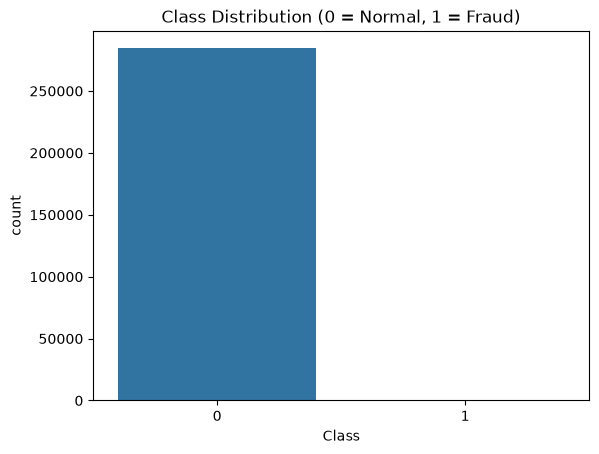

In [6]:
sns.countplot(x='Class', data=data)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

In [7]:
X = data.drop('Class', axis=1)
y = data['Class']

In [8]:
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1,1))
X['Time'] = scaler.fit_transform(X['Time'].values.reshape(-1,1))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

normal_sample = normal.sample(len(fraud), random_state=42)

balanced_data = pd.concat([fraud, normal_sample])

balanced_data = balanced_data.sample(frac=1, random_state=42)

X_bal = balanced_data.drop('Class', axis=1)
y_bal = balanced_data['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, proba_lr))

LOGISTIC REGRESSION
[[ 86   1]
 [ 10 100]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        87
           1       0.99      0.91      0.95       110

    accuracy                           0.94       197
   macro avg       0.94      0.95      0.94       197
weighted avg       0.95      0.94      0.94       197

ROC-AUC: 0.9828631138975967


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))

RANDOM FOREST
[[84  3]
 [12 98]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        87
           1       0.97      0.89      0.93       110

    accuracy                           0.92       197
   macro avg       0.92      0.93      0.92       197
weighted avg       0.93      0.92      0.92       197

ROC-AUC: 0.9845872518286312


In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST")
print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, proba_xgb))

XGBOOST
[[ 83   4]
 [  9 101]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        87
           1       0.96      0.92      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197

ROC-AUC: 0.9850574712643678


In [36]:
proba_lr = lr.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, proba_lr)

In [37]:
proba_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, proba_rf)

In [38]:
proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, proba_xgb)

In [39]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf, roc_auc_xgb]
})

print(results_df)

                 Model   ROC-AUC
0  Logistic Regression  0.982863
1        Random Forest  0.984587
2              XGBoost  0.985057
